<a href="https://colab.research.google.com/github/jellybbie/study/blob/save2/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

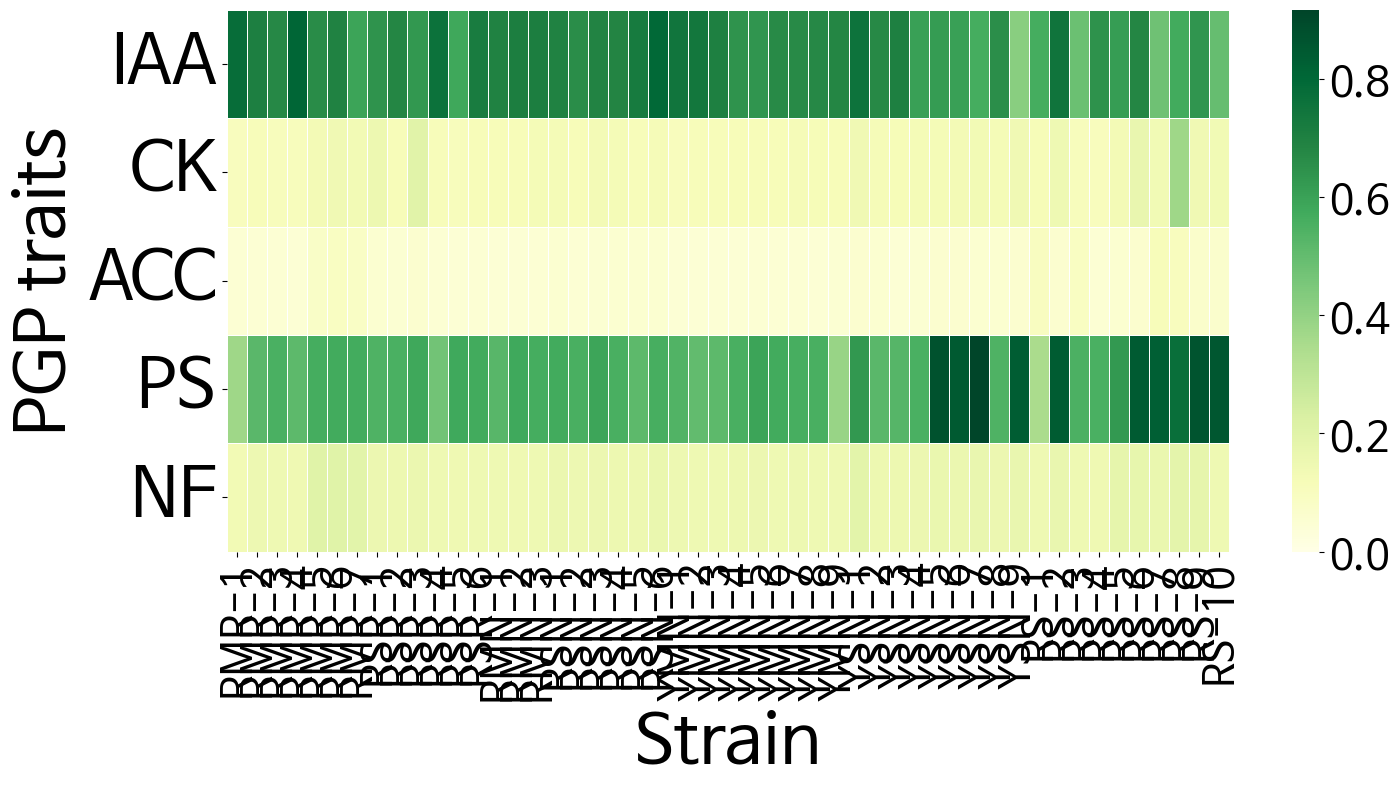

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for log transformation

file_path = '/content/screening(2025)-6.xlsx'
df = pd.read_excel(file_path)

# Abbreviated feature names as requested
features = ['IAA', 'CK', 'ACC', 'PS', 'NF']

# Select and rename columns for the heatmap
heatmap_data_transposed = df.set_index('Strain')[['IAA production', 'Cytokinin production', 'ACC deaminase activity', 'Phosphate solubilization', 'Nitrogen fixation']].T
heatmap_data_transposed.index = features # Apply abbreviated names to the index

# Apply log1p transformation to make low values more distinguishable
# log1p(x) computes log(1+x), which is useful for data with values close to zero
heatmap_data_transformed = np.log1p(heatmap_data_transposed)

# Display only a subset of strains for better readability
# For example, let's display the first 50 strains
subset_strains = heatmap_data_transformed.iloc[:, :50] # Select first 50 columns (strains)

# Adjust figure width dynamically for the subset of strains
num_strains_subset = subset_strains.shape[1]
fig_width_subset = max(15, num_strains_subset * 0.3) # Give more space per strain for better visibility

plt.figure(figsize=(fig_width_subset, 8)) # Adjust figure size for better readability, increased height to 8
ax = sns.heatmap(subset_strains, cmap='YlGn', annot=False, fmt=".4f", linewidths=.5, vmin=0)
cbar = ax.collections[0].colorbar
cbar.set_label('') # Removed label text
cbar.ax.tick_params(labelsize=30) # Set fontsize for colorbar tick labels
# plt.title('Log Transformed Feature Values Heatmap for First 50 Strains') # Removed title as requested
plt.xlabel('Strain', fontsize=50) # Changed x-axis label font size to 50
plt.ylabel('PGP traits', fontsize=50) # Changed y-axis label and increased font size
plt.xticks(rotation=90, fontsize=30) # Rotate x-axis labels if they overlap, changed font size to 30
plt.yticks(rotation=0, fontsize=50) # Ensure feature names are readable, increased font size
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Remaining Strains Heatmaps (in 50-unit batches)

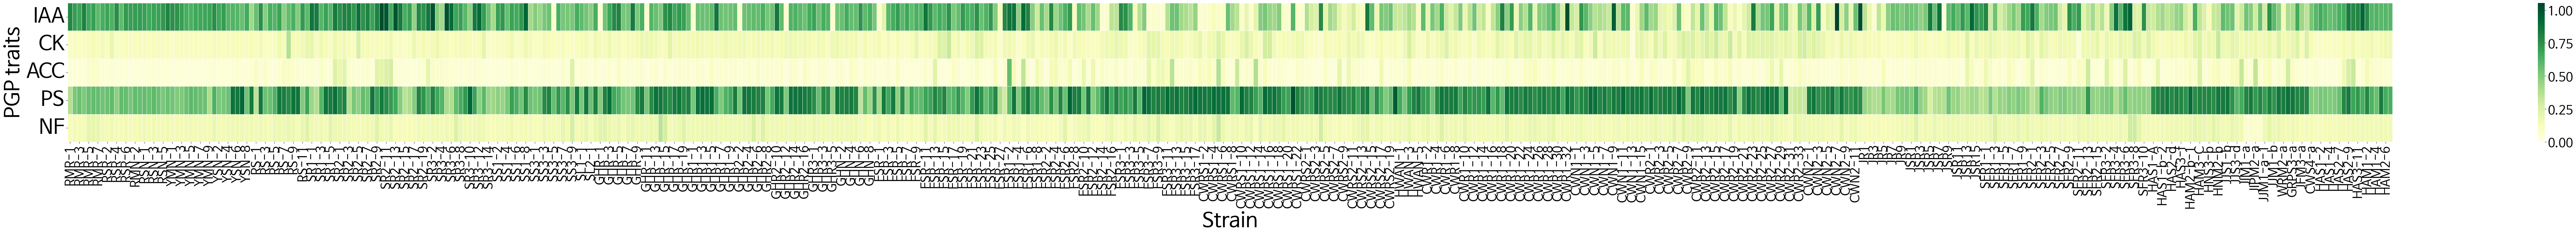

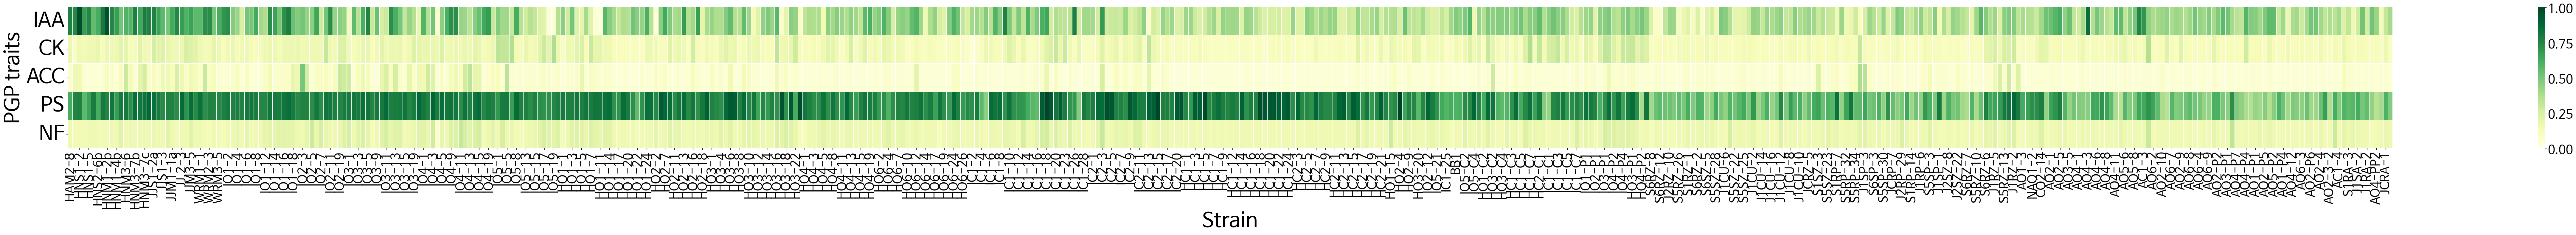

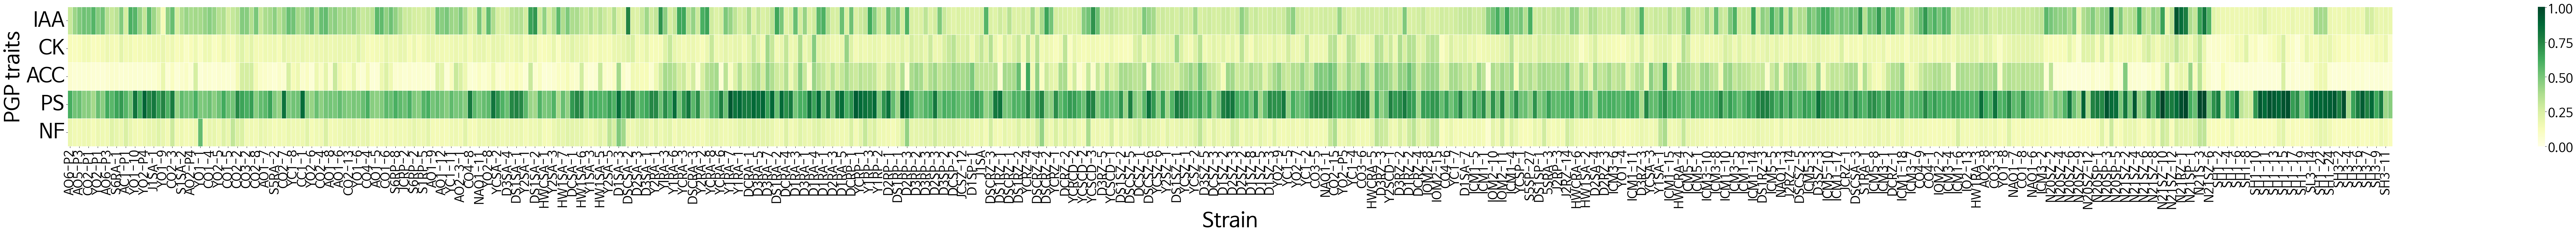

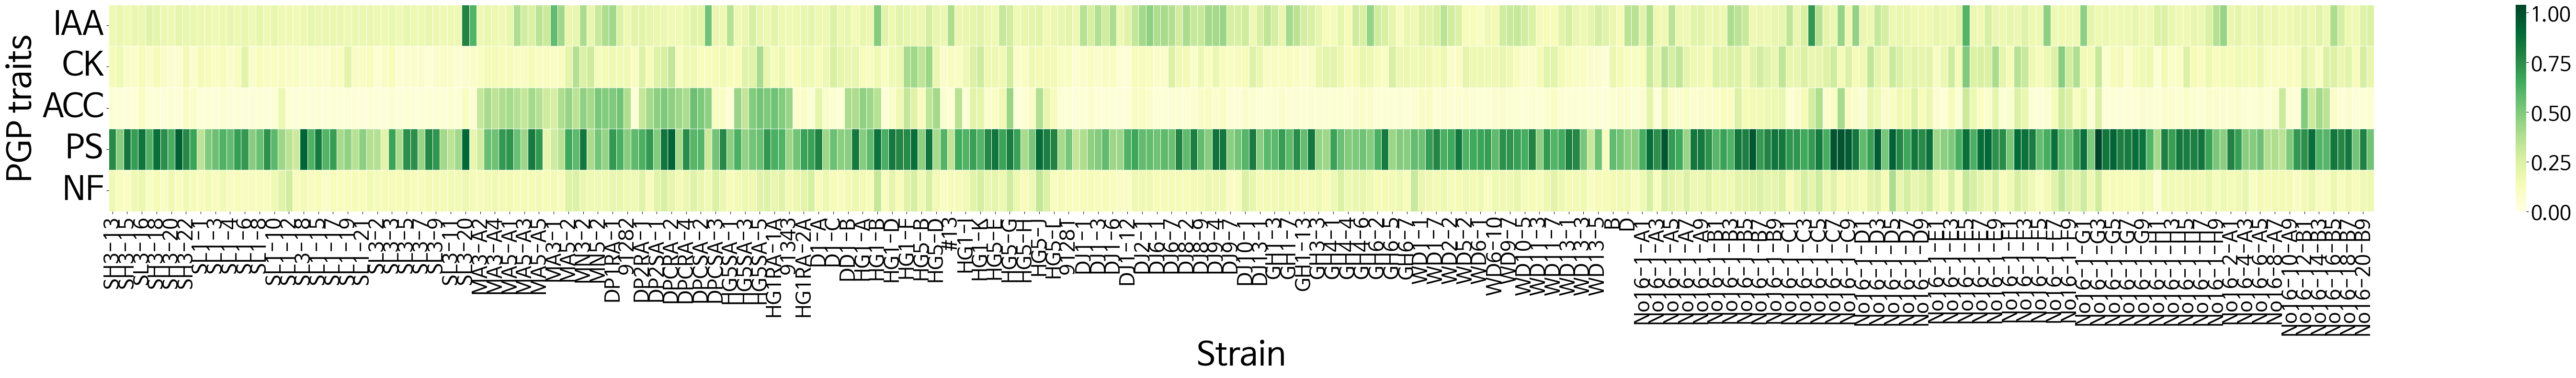

In [37]:
# Iterate through the remaining strains in batches of 200
num_total_strains = heatmap_data_transformed.shape[1]
batch_size = 500 # Changed batch size to 500

for i in range(0, num_total_strains, batch_size):
    start_idx = i
    end_idx = min(i + batch_size, num_total_strains)

    current_batch_strains = heatmap_data_transformed.iloc[:, start_idx:end_idx]

    if current_batch_strains.empty:
        continue

    num_strains_in_batch = current_batch_strains.shape[1]
    # Adjust width for current batch, giving more space per strain
    fig_width_batch = max(15, num_strains_in_batch * 0.2) # Adjusted multiplier for wider batches

    plt.figure(figsize=(fig_width_batch, 8))
    ax = sns.heatmap(current_batch_strains, cmap='YlGn', annot=False, fmt=".4f", linewidths=.5, vmin=0)
    cbar = ax.collections[0].colorbar
    cbar.set_label('') # Removed label text
    cbar.ax.tick_params(labelsize=30) # Set fontsize for colorbar tick labels
    # plt.title(f'Log Transformed Feature Values Heatmap for Strains {start_idx + 1} to {end_idx}') # Removed title as requested
    plt.xlabel('Strain', fontsize=50) # Changed x-axis label font size to 50
    plt.ylabel('PGP traits', fontsize=50) # Changed y-axis label and increased font size
    plt.xticks(rotation=90, fontsize=30) # Rotate x-axis labels if they overlap, changed font size to 30
    plt.yticks(rotation=0, fontsize=50) # Ensure feature names are readable, increased font size
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

## 히트맵 생성 함수

다른 데이터를 불러왔을 때에도 동일한 방식으로 히트맵을 그릴 수 있도록, 히트맵 생성 로직을 함수로 정의합니다.

이 `plot_feature_heatmap` 함수는 다음을 수행합니다:

1.  **데이터 전처리:** 주어진 데이터프레임에서 필요한 특성(`features` 리스트에 정의된 'IAA production', 'Cytokinin production', 등)을 선택하고, 'Strain' 컬럼을 인덱스로 설정합니다. 이후 Y축 라벨을 약어(`['IAA', 'CK', 'ACC', 'PS', 'NF']`)로 변경합니다.
2.  **로그 변환:** 낮은 값들의 구분을 더 명확히 하기 위해 `np.log1p` 변환을 적용합니다.
3.  **히트맵 생성:** `seaborn.heatmap`을 사용하여 히트맵을 그립니다.
    *   `cmap='YlGn'` (색상 맵)을 사용합니다.
    *   `annot=False` (셀 내 숫자 주석 없음).
    *   `fmt=".4f"` (숫자 형식, 주석을 사용할 경우).
    *   `linewidths=.5` (셀 경계선 두께).
    *   `vmin=0` (색상 스케일 최소값 고정).
4.  **스타일 설정:**
    *   그래프 제목을 제거합니다.
    *   X축 제목은 'Strain' (글씨 크기 50), Y축 제목은 'PGP traits' (글씨 크기 50)로 설정합니다.
    *   X축 틱 라벨은 글씨 크기 30, Y축 틱 라벨은 글씨 크기 50으로 설정합니다.
    *   컬러바(스케일바) 제목을 제거하고, 숫자 글씨 크기를 30으로 설정합니다.
5.  **배치 처리:** 전체 데이터를 지정된 `batch_size` (기본값 500) 단위로 나누어 여러 개의 히트맵을 생성하여 표시합니다.

이 함수를 사용하면 새로운 엑셀 파일을 로드한 후, 단 한 줄의 코드로 복잡한 히트맵 시각화를 생성할 수 있습니다.

In [38]:
def plot_feature_heatmap(df_input, features_map=None, batch_size=500, colormap='YlGn'):
    """
    주어진 데이터프레임에서 특정 특성들을 사용하여 히트맵을 생성하고 시각화합니다.

    Args:
        df_input (pd.DataFrame): 'Strain' 컬럼과 특성 컬럼을 포함하는 입력 데이터프레임입니다.
        features_map (dict): 원래 특성 이름과 히트맵에 표시할 약어 간의 매핑입니다.
                           None인 경우 기본 매핑을 사용합니다.
        batch_size (int): 히트맵을 생성할 Strain의 배치 크기입니다.
        colormap (str): 히트맵에 사용할 색상 맵입니다.
    """

    if features_map is None:
        # Default feature mapping
        original_features = ['IAA production', 'Cytokinin production', 'ACC deaminase activity', 'Phosphate solubilization', 'Nitrogen fixation']
        abbreviated_features = ['IAA', 'CK', 'ACC', 'PS', 'NF']
        features_map = dict(zip(original_features, abbreviated_features))
    else:
        original_features = list(features_map.keys())
        abbreviated_features = list(features_map.values())

    # Select and rename columns for the heatmap
    heatmap_data_transposed = df_input.set_index('Strain')[original_features].T
    heatmap_data_transposed.index = abbreviated_features # Apply abbreviated names to the index

    # Apply log1p transformation to make low values more distinguishable
    heatmap_data_transformed = np.log1p(heatmap_data_transposed)

    num_total_strains = heatmap_data_transformed.shape[1]

    for i in range(0, num_total_strains, batch_size):
        start_idx = i
        end_idx = min(i + batch_size, num_total_strains)

        current_batch_strains = heatmap_data_transformed.iloc[:, start_idx:end_idx]

        if current_batch_strains.empty:
            continue

        num_strains_in_batch = current_batch_strains.shape[1]
        fig_width_batch = max(15, num_strains_in_batch * 0.2)

        plt.figure(figsize=(fig_width_batch, 8))
        ax = sns.heatmap(current_batch_strains, cmap=colormap, annot=False, fmt=".4f", linewidths=.5, vmin=0)
        cbar = ax.collections[0].colorbar
        cbar.set_label('')
        cbar.ax.tick_params(labelsize=30)

        plt.xlabel('Strain', fontsize=50)
        plt.ylabel('PGP traits', fontsize=50)
        plt.xticks(rotation=90, fontsize=30)
        plt.yticks(rotation=0, fontsize=50)
        plt.tight_layout()
        plt.show()

print("Heatmap plotting function defined: plot_feature_heatmap")

Heatmap plotting function defined: plot_feature_heatmap


### 함수 사용 예시

기존 `df` 데이터를 사용하여 함수를 호출하여 히트맵을 생성합니다. 이전에 설정했던 모든 시각적 옵션이 함수 내에 포함되어 있어 단 한 줄로 동일한 결과를 얻을 수 있습니다.

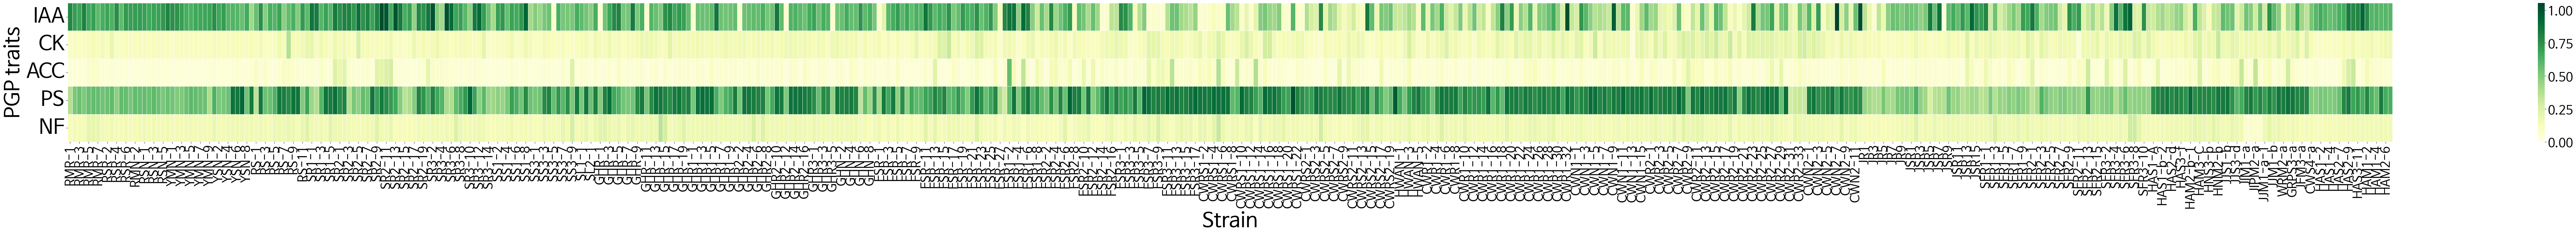

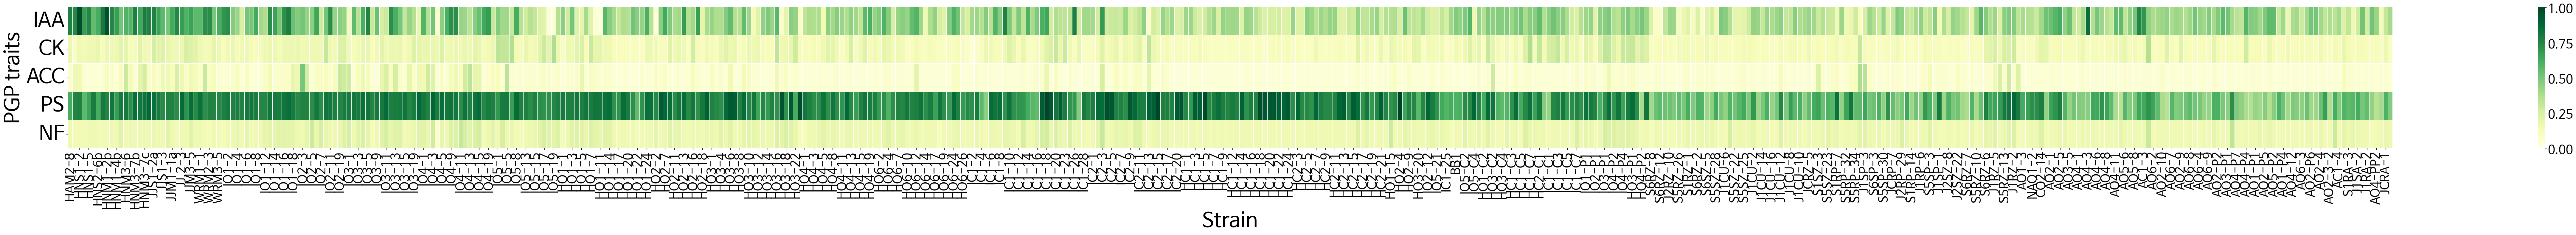

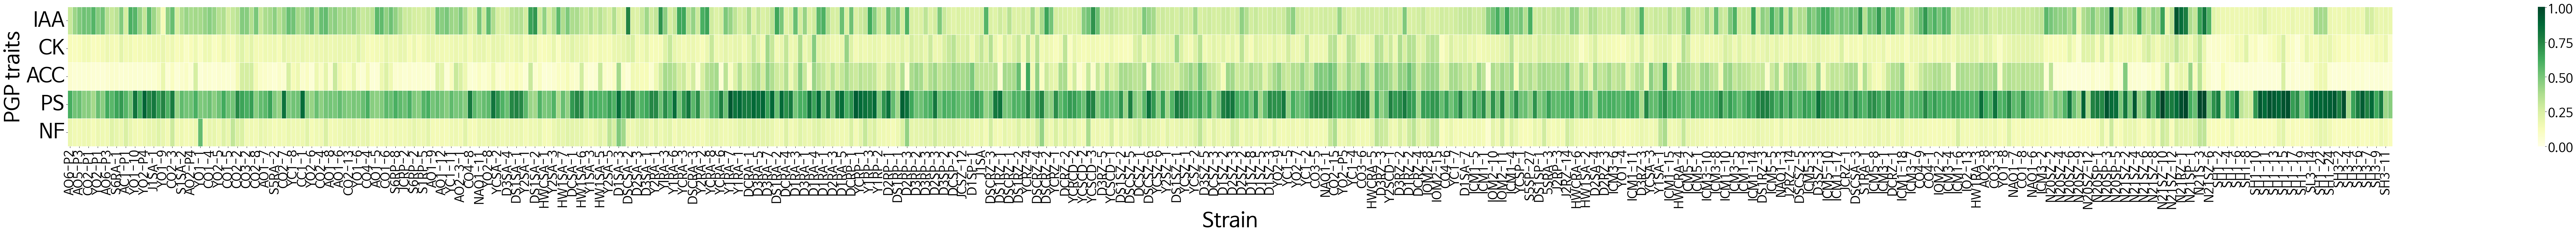

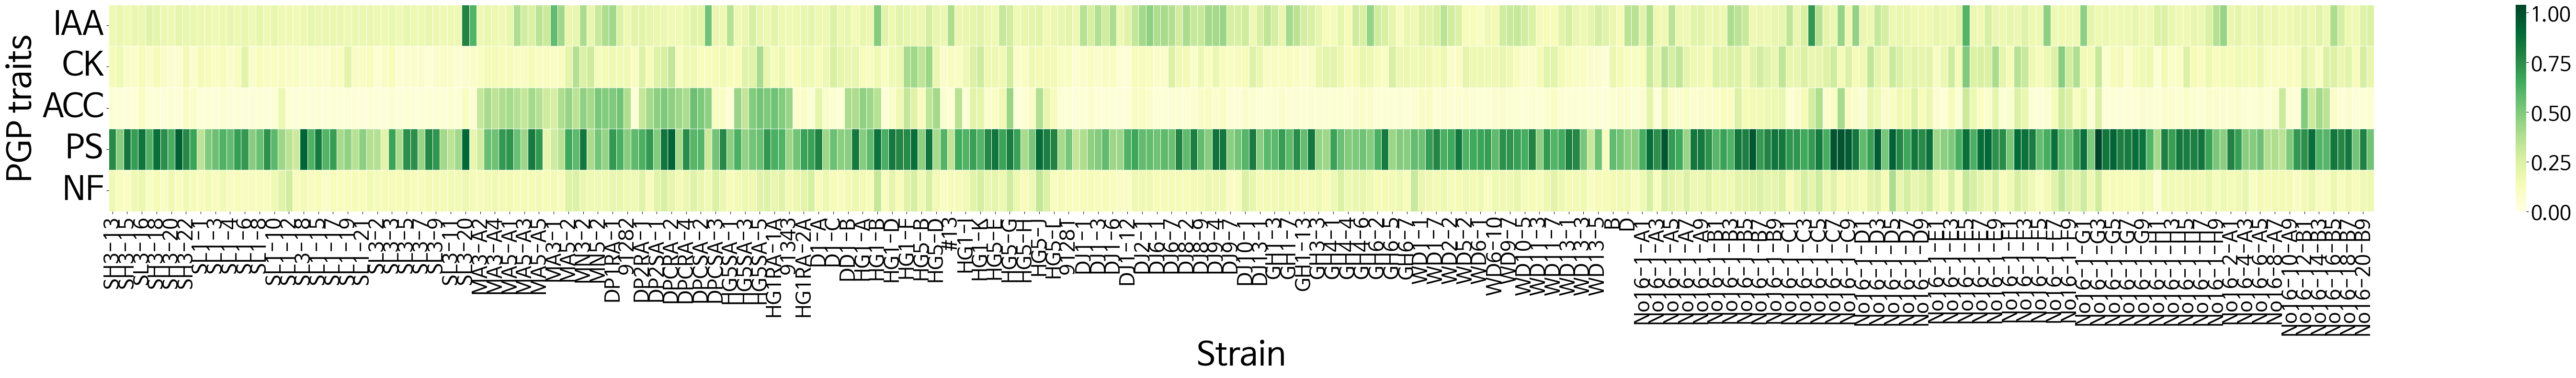

In [39]:
plot_feature_heatmap(df)

In [13]:
# Check descriptive statistics of the heatmap data
display(heatmap_data_transposed.describe())

Strain,RMR-1,RMR-2,RMR-3,RMR-4,RMR-5,RMR-6,RMR-7,RSR-1,RSR-2,RSR-3,...,No16-12-B1,No16-13-B2,No16-14-B3,No16-15-B4,No16-16-B5,No16-17-B6,No16-18-B7,No16-19-B8,No16-20-B9,No16-21-B10
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.386360,0.408640,0.405280,0.446840,0.429200,0.450220,0.402600,0.403500,0.410340,0.423420,...,0.478420,0.467260,0.368220,0.369400,0.469160,0.371980,0.401300,0.239200,0.402480,0.290460
std,0.469833,0.426986,0.417001,0.509433,0.391581,0.411438,0.352835,0.379153,0.417331,0.377277,...,0.395554,0.526848,0.309934,0.274992,0.494042,0.447838,0.511947,0.262274,0.457023,0.245426
min,0.048800,0.049100,0.048600,0.046900,0.085700,0.095000,0.086600,0.057500,0.051400,0.061400,...,0.162000,0.186400,0.112300,0.126400,0.088900,0.058000,0.072900,0.043600,0.058000,0.062700
25%,0.108400,0.120600,0.116400,0.116600,0.139100,0.153500,0.141700,0.167000,0.121800,0.176600,...,0.226000,0.194000,0.119600,0.195000,0.195900,0.135500,0.179000,0.136500,0.176500,0.187100
50%,0.142500,0.162800,0.158800,0.156500,0.223900,0.224700,0.213500,0.173900,0.166800,0.217900,...,0.262000,0.201500,0.257000,0.283000,0.266700,0.202300,0.195000,0.137900,0.262000,0.219000
75%,0.453400,0.685800,0.736700,0.670700,0.756000,0.772600,0.764300,0.717600,0.736900,0.788500,...,0.639900,0.352800,0.510300,0.423000,0.479000,0.308000,0.249700,0.178000,0.314500,0.277000
max,1.178700,1.024900,0.965900,1.243500,0.941300,1.005300,0.806900,0.901500,0.974800,0.872700,...,1.102200,1.401600,0.841900,0.819600,1.315300,1.156100,1.309900,0.700000,1.201400,0.706500


In [14]:
print('DataFrame의 처음 5개 행을 표시합니다:')
display(df.head())

DataFrame의 처음 5개 행을 표시합니다:


,Strain,IAA production,Cytokinin production,ACC deaminase activity,Phosphate solubilization,Nitrogen fixation
0,RMR-1,1.1787,0.1084,0.0488,0.4534,0.1425
1,RMR-2,1.0249,0.1206,0.0491,0.6858,0.1628
2,RMR-3,0.9659,0.1164,0.0486,0.7367,0.1588
3,RMR-4,1.2435,0.1166,0.0469,0.6707,0.1565
4,RMR-5,0.9413,0.1391,0.0857,0.7560,0.2239
